# Exercises week 37

**FYS-STK3155/4155, fall 2026 — deadline Friday September 11 at midnight.**

## Implementing gradient descent for ordinary least squares and Ridge regression

The aim this week is that you write, and *check*, your own gradient descent
code for OLS and Ridge regression, and that you understand what the learning
rate can and cannot be. Everything here is reused directly in part e) of
Project 1, and exercise 6 opens part f). The code developed in the Tuesday
session (`week37tuesday.ipynb`, Case 1) is meant to be reused.

After completing these exercises you will have

* your own code for the simplest gradient descent approach applied to
  ordinary least squares (OLS) and Ridge regression, with a stopping criterion;
* compared the analytical expressions for the OLS and Ridge parameters with
  the gradient descent results;
* explored the role of the learning rate $\eta$ in gradient descent and of the
  hyperparameter $\lambda$ in Ridge regression, and related the largest usable
  learning rate to the largest eigenvalue of the Hessian (Section 4.5 of the
  lecture notes);
* checked your analytical gradient against automatic differentiation
  (Section 4.14) and added momentum (Section 4.6);
* scaled the data properly.

Reading: Chapter 4, Sections 4.1–4.6 and 4.14 of the book; Goodfellow et al.,
Chapter 4 and Sections 8.1–8.3.

## A simple one-dimensional second-order polynomial

We start with a very simple function,

$$
f(x) = 2 - x + 5x^2,
$$

defined for $x \in [-2, 2]$. You can add noise if you wish (the Tuesday
session used Gaussian noise with standard deviation $0.5$). We fit this
function with a polynomial ansatz. The easiest thing is to set up a
second-order polynomial and see if you can recover the above function; feel
free to play around with higher-order polynomials — the Tuesday session shows
that a degree-5 fit of the same data is a much harder problem for gradient
descent, and exercise 4 asks you why.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
n = 100
x = rng.uniform(-2.0, 2.0, n)
y = 2.0 - x + 5.0 * x**2 + 0.5 * rng.standard_normal(n)   # drop the noise term if you prefer

## Exercise 1: scale your data

Before fitting a regression model it is good practice to standardise the
features. This ensures all features are on a comparable scale, which is
especially important when using regularisation — and, as Section 4.5 of the
lecture notes shows, it is also what makes gradient descent converge in a
reasonable number of iterations. Here we standardise, scaling each feature to
have mean $0$ and standard deviation $1$.

### 1a)

Set up the design matrix $\boldsymbol{X}$ with the columns $x$ and $x^2$ (no
column of ones). Compute the mean and standard deviation of each column,
subtract the mean and divide by the standard deviation.

We also centre the target $\boldsymbol{y}$ to mean $0$. Centring
$\boldsymbol{y}$ and each feature means the model does not need a separate
intercept term: the data are shifted so that the intercept is effectively
$0$. (In practice one can include an intercept in the model and leave it
unpenalised, see Section 3.13 of the lecture notes; here we simplify by
centring.)

In [2]:
X = np.column_stack([x, x**2])

# Standardize features (zero mean, unit variance for each feature)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_std[X_std == 0] = 1  # safeguard to avoid division by zero for constant features
X_norm = (X - X_mean) / X_std

# Center the target to zero mean (optional, to simplify intercept handling)
y_mean = y.mean()
y_centered = y - y_mean

# Yes we need to centre the y, as otherwise we would be stuck with a 
# constant error y_mean as the model is not allowed to have an intercept term

Fill in the necessary details. Do we need to centre the $y$-values? What
would go wrong, for OLS and for Ridge, if we did not?

After this preprocessing each column of $\boldsymbol{X}_{\mathrm{norm}}$ has
mean zero and standard deviation $1$ and $\boldsymbol{y}_{\mathrm{centered}}$
has mean $0$. This makes the optimisation landscape nicer and ensures that the
penalty $\lambda\sum_j\theta_j^2$ in Ridge regression treats each coefficient
fairly, since the features are on the same scale.

### 1b)

The true function has coefficients $(-1, 5)$ on $(x, x^2)$. Which
coefficients do you expect to find on the *standardised* columns, and how do
you convert the fitted parameters back to the original scale?

#### Answer:

We have standardized each feature $x_j$ to $z_j = (x_j - \mu _j) / \sigma _j$. If the true relation is $y = \beta_1 x + \beta_2 x^2$ (with $\beta_1 = -1$ and $\beta_2 = 5$), then in terms of standardised columns the coefficient on $z_j$ is
$$
\theta_j = \beta_j \sigma_j.
$$
This means that we expect to find the original/true coefficients scaled by each columns standard deviation, *not* -1 and 5.

In order to convert the parameters back to the original scale, we simply have to divide them by the standard deviation (derived form the equation above):
$$
\beta _j = \frac{\theta _j}{\sigma _j}.
$$
In code, this would be to do the following:
```python
beta = theta / X_std
```

## Exercise 2: calculate the gradients and the Hessian

Find the gradients of the OLS and Ridge cost functions,

$$
C_{\mathrm{OLS}}(\boldsymbol{\theta}) = \frac{1}{n}\|\boldsymbol{X}\boldsymbol{\theta} - \boldsymbol{y}\|_2^2,
\qquad
C_{\mathrm{Ridge}}(\boldsymbol{\theta}) = \frac{1}{n}\|\boldsymbol{X}\boldsymbol{\theta} - \boldsymbol{y}\|_2^2 + \lambda\boldsymbol{\theta}^T\boldsymbol{\theta},
$$

with respect to $\boldsymbol{\theta}$ (Eqs. (4.13) and (4.17) of the lecture
notes). Find also the Hessian matrices, and show that the OLS Hessian is
positive semi-definite and the Ridge Hessian positive definite for
$\lambda > 0$ — that is, that both cost functions are convex (Section 4.1).
Why does this matter for gradient descent?

Setting the Ridge gradient to zero, show that the minimiser is
$\hat{\boldsymbol{\theta}} = (\boldsymbol{X}^T\boldsymbol{X} + n\lambda\boldsymbol{I})^{-1}\boldsymbol{X}^T\boldsymbol{y}$.
Where does the factor $n$ come from, and what is the corresponding `alpha`
of `scikit-learn`'s `Ridge`? (Section 3.10 and Eq. (3.95).)


## Solution:

The OLS cost function for a linear model can be written as

$$
\frac{1}{n}
\sum_{i=1}^{n}
\left[
(\theta_0+\theta_1x_i)^2
-2y_i(\theta_0+\theta_1x_i)
+y_i^2
\right].
$$

Taking the gradient with respect to the two parameters gives

$$
\nabla_\theta C(\theta) = \frac2n 
\begin{pmatrix}
    \sum_i (\theta_0 + \theta_1x_i -y_i) \\
    \sum_i (x_i(\theta_0 + \theta_1x_i)-y_ix_i)
\end{pmatrix}
= \frac{2}{n}
\mathbf X^T
\left(
\mathbf X\boldsymbol{\theta}-\mathbf y
\right).
$$

The Hessian is obtained by differentiating the gradient once more with respect to (\boldsymbol{\theta}):
$$
\mathbf{H} = \nabla_{\boldsymbol{\theta}}^2 C(\boldsymbol{\theta}) = \frac{2}{n}\mathbf X^T\mathbf X.
$$

For Ridge, we get

$$
\nabla_\theta C(\theta) = \frac2n \mathbf{X}^T (\mathbf{X\theta-y}) + 2 \lambda \mathbf{\theta},
$$

and

$$
\mathbf{H} = \frac2n \mathbf{X^TX} + 2 \lambda \mathbf{I}.
$$

---

We can show that the two Hessians are positive semi-definite by provind that 

$$
\mathbf{z^T H z} \geq 0 \qquad \text{for all } \mathbf{z}.
$$

### OLS:

$$
\mathbf{z^T H z} = \frac2n z^TX^T X z = (Xz)^T (Xz) = ||Xz||^2.
$$

We know $||Xz||^2 \geq 0$ is true, thus we have shown that the Hessian is positive semi-definite and OLS cost function is convex.

### Ridge

$$
\mathbf{z^T H z} = \frac2n z^TX^TXz + 2\lambda z^t I z = \frac2n ||Xz||^2 +2\lambda ||z||^2.
$$

For $\lambda>0$, this is strictly positive for every $\mathbf z\neq\mathbf 0$. Therefore, the Ridge Hessian is positive definite, making the Ridge cost function strictly convex and ensuring a unique global minimum.

## Exercise 3: the analytical formulae for OLS and Ridge regression

In [3]:
# Set regularization parameter, either a single value or a vector of values
# Note that lambda is a python keyword: the lambda keyword creates small anonymous functions.
lam = 0.25

# Analytical forms: theta_Ridge = (X^T X + n*lambda*I)^{-1} X^T y and theta_OLS = (X^T X)^{-1} X^T y
n_features = X_norm.shape[1]
I = np.eye(n_features)
theta_closed_formRidge = np.linalg.solve(X.T @ X + n * lam * I, X.T @ y)
theta_closed_formOLS = np.linalg.solve(X.T @ X, X.T @ y)

print("Closed-form Ridge coefficients:", theta_closed_formRidge)
print("Closed-form OLS coefficients:", theta_closed_formOLS)

Closed-form Ridge coefficients: [-0.78295395  5.33319758]
Closed-form OLS coefficients: [-1.07769908  5.88335588]


This computes the Ridge and OLS regression coefficients directly. The identity
matrix $\boldsymbol{I}$ has the same size as $\boldsymbol{X}^T\boldsymbol{X}$
and adds $n\lambda$ to its diagonal for Ridge regression. We then solve the
linear system (prefer `np.linalg.solve` or `np.linalg.pinv` to an explicit
inverse). The result for $\boldsymbol{\theta}$ is a NumPy array of shape
`(n_features,)` containing the fitted parameters.

### 3a)

Finalise, in the above code, the OLS and Ridge regression determination of
the optimal parameters $\boldsymbol{\theta}$. Compare with
`Ridge(alpha=n*lam, fit_intercept=False)` from `scikit-learn`.

In [4]:
from sklearn.linear_model import Ridge

sklearn_model = Ridge(alpha=n * lam, fit_intercept=False)
sklearn_ridge = sklearn_model.fit(X, y).coef_
print(f"{sklearn_ridge = }, {theta_closed_formRidge = }")

sklearn_ridge = array([-0.78295395,  5.33319758]), theta_closed_formRidge = array([-0.78295395,  5.33319758])


### 3b)

Explore the results as functions of different values of the hyperparameter
$\lambda$. See for example exercise 4 from week 36, and Section 3.14 of the
lecture notes for how $\lambda$ should be chosen in practice.

In [5]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

lambdas = np.logspace(-6, 3, 10)

# Split the standardized design matrix and centered target
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)
n_train = X_train.shape[0]
n_features = X_train.shape[1]

best_lambda = None
best_mse = np.inf

for lam in lambdas:
    # Fit Ridge on training data
    theta = np.linalg.solve(
        X_train.T @ X_train + n_train * lam * np.eye(n_features),
        X_train.T @ y_train,
    )
    # Predictions
    y_pred_train = X_train @ theta
    y_pred_test = X_test @ theta
    # MSE
    mse_train = mean_squared_error(y_true=y_train, y_pred=y_pred_train)
    mse_test = mean_squared_error(y_true=y_test, y_pred=y_pred_test)
    if mse_test < best_mse:
        best_mse = mse_test
        best_lambda = lam
    print(
        f"lambda={lam:8.3g}  "
        f"mse_train={mse_train:.4f}  "
        f"mse_test={mse_test:.4f}"
    )

print(f"Best lambda: {best_lambda}")
print(f"Best test MSE: {best_mse:.4f}")

lambda=   1e-06  mse_train=2.6822  mse_test=2.3547
lambda=   1e-05  mse_train=2.6822  mse_test=2.3547
lambda=  0.0001  mse_train=2.6822  mse_test=2.3549
lambda=   0.001  mse_train=2.6822  mse_test=2.3570
lambda=    0.01  mse_train=2.6838  mse_test=2.3794
lambda=     0.1  mse_train=2.8279  mse_test=2.7391
lambda=       1  mse_train=10.1186  mse_test=12.7635
lambda=      10  mse_train=55.9103  mse_test=73.4293
lambda=     100  mse_train=80.0203  mse_test=105.6799
lambda=   1e+03  mse_train=83.3074  mse_test=110.0895
Best lambda: 1e-06
Best test MSE: 2.3547


We see little help from the regurlarization. This is because we only have two features and 100 data points, meaning this is a heavily overdetermined and well-conditioned problem. This means that every bit of shrinkage just adds bias without buying back any variance (the MSE for the test grows monotonically with lambda).

## Exercise 4: implementing the simplest form of gradient descent

Alternatively we can fit the model by gradient descent, Eq. (4.15) of the
lecture notes,

$$
\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_k - \eta\,\nabla_{\boldsymbol{\theta}} C(\boldsymbol{\theta}_k).
$$

This is useful to visualise the iterative convergence, and it is necessary
when $n$ and $p$ are so large that the closed form is too slow or too
memory-hungry — or when, as for the Lasso, logistic regression and neural
networks, no closed form exists. Use the gradients of exercise 2 and set up,
using the template below, your own gradient descent code for OLS and Ridge
regression.

In [6]:
# Gradient descent parameters, learning rate eta first
eta = 0.1
# Then the maximum number of iterations, and a tolerance for the stopping criterion
num_iters = 1000
tol = 1e-8

# Initialize weights for gradient descent
theta_gdOLS = np.zeros(n_features)
theta_gdRidge = np.zeros(n_features)

# Gradient descent loop
for t in range(num_iters):
    # Compute gradients for OLS and Ridge
    grad_OLS = (
        2 / n_train
        * X_train.T
        @ (X_train @ theta_gdOLS - y_train)
    )

    grad_Ridge = (
        2 / n_train
        * X_train.T
        @ (X_train @ theta_gdRidge - y_train)
        + 2 * lam * theta_gdRidge
    )

    # Store old parameters for stopping criterion
    theta_OLS_old = theta_gdOLS.copy()
    theta_Ridge_old = theta_gdRidge.copy()

    # Update parameters
    theta_gdOLS -= eta * grad_OLS
    theta_gdRidge -= eta * grad_Ridge

    # Stopping criterion
    if (
        np.linalg.norm(theta_gdOLS - theta_OLS_old) < tol
        or np.linalg.norm(theta_gdRidge - theta_Ridge_old) < tol
    ):
        break


# After the loop, theta contains the fitted coefficients
print("Gradient Descent OLS coefficients:", theta_gdOLS)
print("Gradient Descent Ridge coefficients:", theta_gdRidge)

Gradient Descent OLS coefficients: [-0.95962934  5.86063012]
Gradient Descent Ridge coefficients: [ 3.64981427e+175 -3.38103333e+177]


### 4a)

Write first a gradient descent code for OLS only, using the above template.
Discuss the results as functions of the learning rate and the number of
iterations: for $\eta \in \{0.01, 0.1, 0.5, 0.8\}$, how many iterations are
needed to reach the closed-form solution of exercise 3 to a given accuracy,
say $\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\|_2 < 10^{-6}$?
Plot this distance against the iteration number on a logarithmic scale.



eta = 0.01: 698 iterations
eta =  0.1: 64 iterations
eta =  0.5: did not converge (diverged)
eta =  0.8: did not converge (diverged)


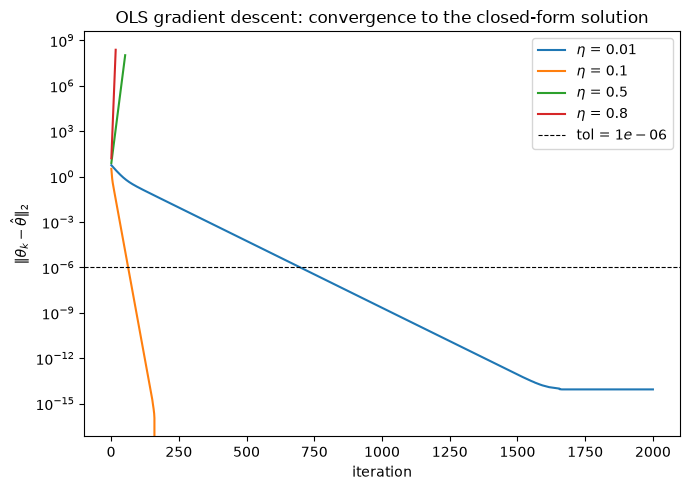

lambda_max(H_OLS) = 4.7580  ->  eta_max = 2/lambda_max = 0.4203


In [7]:
# 4a) Gradient descent for OLS: effect of the learning rate eta

# Closed-form OLS solution on the same (training) data the gradient descent
# below is run on, so that the two are directly comparable, cf. exercise 3.
theta_hat_OLS = np.linalg.solve(X_train.T @ X_train, X_train.T @ y_train)

etas = [0.01, 0.1, 0.5, 0.8]
num_iters = 2000
tol = 1e-6

histories = {}
iters_needed = {}

for eta in etas:
    theta = np.zeros(n_features)
    dist_history = []
    n_reached = None
    for t in range(1, num_iters + 1):
        grad_OLS = 2 / n_train * X_train.T @ (X_train @ theta - y_train)
        theta = theta - eta * grad_OLS
        dist = np.linalg.norm(theta - theta_hat_OLS)
        dist_history.append(dist)
        if n_reached is None and dist < tol:
            n_reached = t
        if not np.isfinite(dist) or dist > 1e8:
            break  # diverged, no point in continuing
    histories[eta] = dist_history
    iters_needed[eta] = n_reached
    status = f"{n_reached} iterations" if n_reached is not None else "did not converge (diverged)"
    print(f"eta = {eta:>4}: {status}")

plt.figure(figsize=(7, 5))
for eta, dist_history in histories.items():
    plt.semilogy(range(1, len(dist_history) + 1), dist_history, label=fr"$\eta$ = {eta}")
plt.axhline(tol, color="k", linestyle="--", linewidth=0.8, label=fr"tol = ${tol:.0e}$")
plt.xlabel("iteration")
plt.ylabel(r"$\|\theta_k - \hat\theta\|_2$")
plt.title("OLS gradient descent: convergence to the closed-form solution")
plt.legend()
plt.tight_layout()
plt.show()

# Largest eigenvalue of the OLS Hessian on the training data (used in exercise 4c)
H_OLS = 2 / n_train * X_train.T @ X_train
eigs_OLS = np.linalg.eigvalsh(H_OLS)
print(f"lambda_max(H_OLS) = {eigs_OLS[-1]:.4f}  ->  eta_max = 2/lambda_max = {2 / eigs_OLS[-1]:.4f}")

**Discussion.** With this data set, $\lambda_{\max}(\boldsymbol H_{\mathrm{OLS}}) \approx 4.76$, so stability
requires $\eta < 2/\lambda_{\max} \approx 0.42$ (Eq. (4.20)). This is exactly what the numbers show:

| $\eta$ | iterations to $\|\theta_k-\hat\theta\|_2<10^{-6}$ |
|---|---|
| 0.01 | 698 |
| 0.1  | 64 |
| 0.5  | diverges |
| 0.8  | diverges |

* $\eta = 0.01$ and $\eta = 0.1$ are both below $\eta_{\max}\approx 0.42$ and converge, but $\eta=0.01$ needs
  roughly $10\times$ as many iterations as $\eta = 0.1$: a smaller step shrinks the error by a smaller factor
  $|1-\eta\lambda|$ each iteration, so more steps are needed for the same accuracy — too small a learning rate
  just wastes iterations.
* $\eta = 0.5$ and $\eta = 0.8$ are both above $\eta_{\max}$. The step overshoots the minimum along the
  steepest direction ($1-\eta\lambda_{\max} < -1$), and the iterates grow without bound instead of shrinking —
  this is exactly what happened to the Ridge run in the un-edited template above, and is fixed in 4b.
* There is a sweet spot: making $\eta$ larger *helps* convergence right up until it crosses $\eta_{\max}$, at
  which point it stops converging altogether. Section 4.5 shows the fastest choice is
  $\eta^\star = 2/(\lambda_{\max}+\lambda_{\min})$, which for this problem is safely inside $(0, \eta_{\max})$
  and between the two convergent values tried here.

### 4b)

Write then a similar code for Ridge regression. Add a stopping criterion
based on the number of iterations *and* on the size of the gradient (or on
the difference between the new and old $\boldsymbol{\theta}$). How would you
define a stopping criterion, and what goes wrong with a fixed number of
iterations alone?

Gradient descent Ridge coefficients: [-0.7179014   5.29051814]
Closed-form Ridge coefficients:      [-0.7179014   5.29051815]
Stopped after 69 iterations, ||grad|| = 8.34e-09, ||theta_k - theta_hat|| = 2.49e-09

Fixed iteration budgets, chosen without checking the gradient:
  budget =  10 iters:  ||grad|| = 2.19e-01, ||theta - theta_hat|| = 6.45e-02
  budget =  20 iters:  ||grad|| = 1.20e-02, ||theta - theta_hat|| = 3.57e-03
  budget =  30 iters:  ||grad|| = 6.64e-04, ||theta - theta_hat|| = 1.98e-04


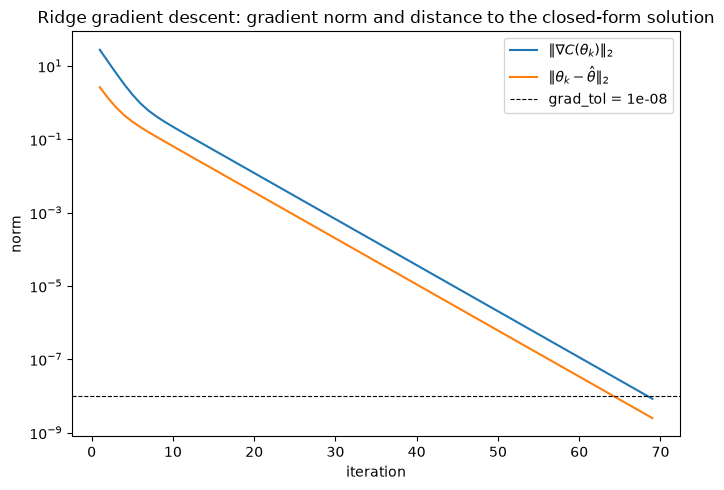

In [8]:
# 4b) Gradient descent for Ridge regression, with a proper stopping criterion

# Set eta and lambda explicitly here. (`lam` was otherwise left over at 1e3,
# the last value of the lambdas sweep in exercise 3b -- that leftover value is
# exactly why the un-edited Ridge run in the template above diverges:
# eta * 2*lam = 0.1 * 2000 = 200, far outside the stability region
# eta < 2/lambda_max derived in exercise 4c.)
eta = 0.1
lam = 0.25

grad_tol = 1e-8     # stop once the gradient is essentially zero ...
num_iters = 5000     # ... but never run forever if something is wrong

theta_hat_Ridge = np.linalg.solve(
    X_train.T @ X_train + n_train * lam * np.eye(n_features), X_train.T @ y_train
)

theta = np.zeros(n_features)
grad_history = []
dist_history = []
iters_used = num_iters

for t in range(1, num_iters + 1):
    grad_Ridge = 2 / n_train * X_train.T @ (X_train @ theta - y_train) + 2 * lam * theta
    theta = theta - eta * grad_Ridge
    grad_history.append(np.linalg.norm(grad_Ridge))
    dist_history.append(np.linalg.norm(theta - theta_hat_Ridge))
    if grad_history[-1] < grad_tol:
        iters_used = t
        break

print(f"Gradient descent Ridge coefficients: {theta}")
print(f"Closed-form Ridge coefficients:      {theta_hat_Ridge}")
print(
    f"Stopped after {iters_used} iterations, ||grad|| = {grad_history[-1]:.2e}, "
    f"||theta_k - theta_hat|| = {dist_history[-1]:.2e}"
)

# What goes wrong with a fixed iteration budget alone: rerun with a budget
# chosen up front, without looking at the gradient, and see how far off it is.
print("\nFixed iteration budgets, chosen without checking the gradient:")
for fixed_budget in [10, 20, 30]:
    theta_fixed = np.zeros(n_features)
    for t in range(fixed_budget):
        grad = 2 / n_train * X_train.T @ (X_train @ theta_fixed - y_train) + 2 * lam * theta_fixed
        theta_fixed -= eta * grad
    print(
        f"  budget = {fixed_budget:>3} iters:  ||grad|| = {np.linalg.norm(grad):.2e}, "
        f"||theta - theta_hat|| = {np.linalg.norm(theta_fixed - theta_hat_Ridge):.2e}"
    )

plt.figure(figsize=(7, 5))
plt.semilogy(range(1, len(grad_history) + 1), grad_history, label=r"$\|\nabla C(\theta_k)\|_2$")
plt.semilogy(range(1, len(dist_history) + 1), dist_history, label=r"$\|\theta_k - \hat\theta\|_2$")
plt.axhline(grad_tol, color="k", linestyle="--", linewidth=0.8, label=f"grad_tol = {grad_tol:.0e}")
plt.xlabel("iteration")
plt.ylabel("norm")
plt.title("Ridge gradient descent: gradient norm and distance to the closed-form solution")
plt.legend()
plt.tight_layout()
plt.show()

**Stopping criterion.** The loop stops as soon as *either* condition below is met:

* $\|\nabla C(\theta_k)\|_2 < \texttt{grad\_tol}$ — the iterate is (numerically) at a stationary point of a
  convex function, hence at the minimum, Eq. (4.16) — or
* a maximum number of iterations `num_iters` is reached, as a safety net in case $\eta$ is too large (no
  convergence) or `grad_tol` is unreachable in floating point.

Here this stops after 69 iterations, with $\|\nabla C\|_2 \approx 8\times10^{-9}$ and
$\|\theta_k-\hat\theta\|_2\approx 2.5\times10^{-9}$: essentially exact agreement with the closed-form Ridge
solution.

**What goes wrong with a fixed iteration count alone.** A budget has to be guessed *before* knowing how the
particular $(\eta,\lambda,\boldsymbol X)$ combination behaves. Picking too small a budget stops the run before
it has converged, silently:

| fixed budget | $\|\nabla C\|_2$ | $\|\theta_k-\hat\theta\|_2$ |
|---|---|---|
| 10  | $2.2\times10^{-1}$ | $6.5\times10^{-2}$ |
| 20  | $1.2\times10^{-2}$ | $3.6\times10^{-3}$ |
| 30  | $6.6\times10^{-4}$ | $2.0\times10^{-4}$ |
| 69 (gradient-based) | $8.3\times10^{-9}$ | $2.5\times10^{-9}$ |

A run capped at, say, 20 iterations *looks* finished — it ran to completion without error — but the
coefficients are still off by $3.6\times10^{-3}$, and nothing in the output flags this. Worse, the "right"
budget is not a fixed number in general: it depends on $\eta$, on $\lambda$, and on the condition number of the
Hessian (exercise 4c) — the same fixed budget that is enough here would be far too small for the ill-conditioned
degree-5 fit, and wasteful for an even better-conditioned problem. A stopping criterion on the gradient (or on
$\|\theta_k-\theta_{k-1}\|$) adapts automatically to whichever problem it is run on, while a bare iteration count
does not — it only bounds the *worst case* runtime, and should be kept only as that safety net, not as the
primary criterion.

### 4c) The learning rate and the eigenvalues of the Hessian

Compute the eigenvalues $\lambda_{\max}$ and $\lambda_{\min}$ of the Hessian
matrix of exercise 2 (use `np.linalg.eigvalsh`). Section 4.5 of the lecture
notes shows that gradient descent converges if and only if
$\eta < 2/\lambda_{\max}$, Eq. (4.20), that the fastest convergence is
obtained for $\eta^* = 2/(\lambda_{\max} + \lambda_{\min})$, and that the
number of iterations grows with the condition number
$\kappa = \lambda_{\max}/\lambda_{\min}$, Eq. (4.21). Verify the bound
numerically: run your code at $0.99 \cdot 2/\lambda_{\max}$ and at
$1.02 \cdot 2/\lambda_{\max}$.

Repeat for a design matrix with the columns $x, x^2, \dots, x^5$
(standardised). What happens to $\kappa$, to $\eta_{\max}$ and to the number
of iterations, and why? Which of the two data sets does Ridge regression help
more, and in what sense?

In [9]:
# 4c) The learning rate and the eigenvalues of the Hessian

def hessian_eigs(Xs, lam=0.0):
    """Smallest and largest eigenvalue of the (OLS/Ridge) Hessian 2/n X^T X + 2*lam*I."""
    p = Xs.shape[1]
    H = 2 / Xs.shape[0] * Xs.T @ Xs + 2 * lam * np.eye(p)
    eigs = np.linalg.eigvalsh(H)
    return eigs[0], eigs[-1]


def gd_OLS_iters(Xs, ytarget, eta, num_iters=300_000, tol=1e-6):
    """Plain OLS gradient descent; report iterations to reach the closed form, or divergence."""
    theta_hat = np.linalg.solve(Xs.T @ Xs, Xs.T @ ytarget)
    theta = np.zeros(Xs.shape[1])
    for t in range(1, num_iters + 1):
        grad = 2 / Xs.shape[0] * Xs.T @ (Xs @ theta - ytarget)
        theta = theta - eta * grad
        dist = np.linalg.norm(theta - theta_hat)
        if not np.isfinite(dist) or dist > 1e8:
            return "diverged", t
        if dist < tol:
            return "converged", t
    return "budget exhausted", num_iters


# Data set 1: degree 2, columns (x, x^2), standardised -- reuse X_norm from exercise 1
X2_norm = X_norm

# Data set 2: degree 5, columns (x, x^2, ..., x^5), standardised the same way
X5_raw = np.column_stack([x**k for k in range(1, 6)])
X5_mean, X5_std = X5_raw.mean(axis=0), X5_raw.std(axis=0)
X5_norm = (X5_raw - X5_mean) / X5_std

for name, Xs in [("degree 2  (x, x^2)", X2_norm), ("degree 5  (x,...,x^5)", X5_norm)]:
    lmin, lmax = hessian_eigs(Xs)
    kappa = lmax / lmin
    eta_max = 2 / lmax
    eta_star = 2 / (lmax + lmin)
    print(
        f"\n{name}: lambda_min={lmin:.4g}, lambda_max={lmax:.4g}, "
        f"kappa={kappa:.4g}, eta_max=2/lambda_max={eta_max:.4g}, eta*={eta_star:.4g}"
    )
    for factor in [0.99, 1.02]:
        eta = factor * eta_max
        status, t = gd_OLS_iters(Xs, y_centered, eta)
        print(f"  eta = {factor} * eta_max = {eta:.4g}: {status} (t = {t})")
    status, t = gd_OLS_iters(Xs, y_centered, eta_star)
    print(f"  eta = eta*            = {eta_star:.4g}: {status} (t = {t})")

# Keep the degree-5 Hessian spectrum around for exercise 6 (momentum), which
# reuses this data set and eta = 0.9 * 2/lambda_max.
lambda_min_5, lambda_max_5 = hessian_eigs(X5_norm)
kappa_5 = lambda_max_5 / lambda_min_5
eta_max_5 = 2 / lambda_max_5

# Does Ridge help more for the well- or the ill-conditioned data set?
lam_c = 0.25
print(f"\nRidge with lambda = {lam_c}: effect on the condition number")
for name, Xs in [("degree 2", X2_norm), ("degree 5", X5_norm)]:
    lmin, lmax = hessian_eigs(Xs)
    lmin_r, lmax_r = lmin + 2 * lam_c, lmax + 2 * lam_c
    kappa, kappa_r = lmax / lmin, lmax_r / lmin_r
    print(
        f"  {name}: kappa_OLS = {kappa:.4g}  ->  kappa_Ridge = {kappa_r:.4g}  "
        f"(reduced by {kappa / kappa_r:.2f}x)"
    )


degree 2  (x, x^2): lambda_min=1.763, lambda_max=2.237, kappa=1.269, eta_max=2/lambda_max=0.8941, eta*=0.5
  eta = 0.99 * eta_max = 0.8851: converged (t = 745)
  eta = 1.02 * eta_max = 0.912: diverged (t = 439)
  eta = eta*            = 0.5: converged (t = 8)

degree 5  (x,...,x^5): lambda_min=0.01086, lambda_max=5.653, kappa=520.3, eta_max=2/lambda_max=0.3538, eta*=0.3531
  eta = 0.99 * eta_max = 0.3503: converged (t = 3353)
  eta = 1.02 * eta_max = 0.3609: diverged (t = 498)
  eta = eta*            = 0.3531: converged (t = 3410)

Ridge with lambda = 0.25: effect on the condition number
  degree 2: kappa_OLS = 1.269  ->  kappa_Ridge = 1.209  (reduced by 1.05x)
  degree 5: kappa_OLS = 520.3  ->  kappa_Ridge = 12.04  (reduced by 43.20x)


**Discussion.**

| data set | $\lambda_{\min}$ | $\lambda_{\max}$ | $\kappa$ | $\eta_{\max}=2/\lambda_{\max}$ | $\eta^\star=2/(\lambda_{\max}+\lambda_{\min})$ |
|---|---|---|---|---|---|
| degree 2 ($x,x^2$) | 1.76 | 2.24 | **1.27** | 0.894 | 0.500 |
| degree 5 ($x,\dots,x^5$) | 0.0109 | 5.65 | **520** | 0.354 | 0.353 |

*Verifying the bound $\eta<2/\lambda_{\max}$.* For both data sets, $\eta = 0.99\,\eta_{\max}$ converges and
$\eta=1.02\,\eta_{\max}$ diverges — a $3\%$ change in $\eta$ flips the run from convergent to unbounded, exactly
at the threshold predicted by Eq. (4.20). Degree 2 needs 745 iterations right at the edge (vs. only 8 at
$\eta^\star$); degree 5 needs 3353 iterations right at the edge (vs. 3410 at $\eta^\star$, i.e. no real
improvement at all — see below).

*What happens going from degree 2 to degree 5.* Standardising removes the effect of each column's own scale
(exercise 1), so the remaining ill-conditioning is purely the correlation between the polynomial columns: $x$
and $x^2$ are only mildly correlated, but $x,x^2,\dots,x^5$ are strongly correlated with each other on
$x\in[-2,2]$ (a high-degree monomial basis is nearly collinear). This shows up entirely in $\lambda_{\min}$,
which collapses from $1.76$ to $0.0109$, while $\lambda_{\max}$ changes comparatively little; $\kappa$ therefore
explodes from $1.27$ to $520$ ($\kappa(\boldsymbol H)=\kappa_2(\boldsymbol X)^2$, Eq. (4.22)). Consequences:

* $\eta_{\max}$ *shrinks* ($0.894\to0.354$): the step size is capped by the steepest direction, which barely
  changed, so this alone is a modest effect.
* The **iteration count explodes** (8 $\to$ 3410 at the respective optimal $\eta$): convergence in the flattest
  direction goes as $|1-\eta\lambda_{\min}|^t$, and once $\eta$ is capped by $\lambda_{\max}$, a tiny
  $\lambda_{\min}$ means that factor is barely below 1, so it takes far more steps to shrink the error there —
  this is Eq. (4.21)'s $\kappa$-scaling directly.
* For degree 5, $\eta^\star\approx\eta_{\max}$ (0.353 vs 0.354): when $\lambda_{\min}\ll\lambda_{\max}$,
  $2/(\lambda_{\max}+\lambda_{\min})\approx 2/\lambda_{\max}$, so there is essentially no "sweet spot" below the
  stability edge to exploit — unlike degree 2, where $\eta^\star$ is far from $\eta_{\max}$ and buys a
  $\sim\!90\times$ speed-up. This is precisely the "much harder problem for gradient descent" flagged in the
  introduction, and precisely what exercise 6's momentum is meant to fix.

*Where Ridge helps more.* Ridge shifts every eigenvalue up by $2\lambda$, Eq. (4.17), which changes the ratio
$\kappa_{\mathrm{Ridge}}=(\lambda_{\max}+2\lambda)/(\lambda_{\min}+2\lambda)$ far more when $\lambda_{\min}$ is
tiny to start with. At $\lambda=0.25$: degree 2 goes from $\kappa=1.27$ to $1.21$ (barely a $1.05\times$
reduction — consistent with exercise 3b, where Ridge only added bias here), while degree 5 goes from
$\kappa=520$ to $12$ (a $43\times$ reduction). So Ridge helps the **ill-conditioned degree-5 fit** far more —
but in the sense of *optimisation speed* (raising $\lambda_{\min}$ shortens the road for gradient descent), not
necessarily in the sense of *test error*: it is still solving a deliberately different, shrunk problem, and
whether that trade is worth it for prediction accuracy is a separate question from how fast it can be solved.

### 4d) Checking the gradient with automatic differentiation

Project 1, part e), asks you to compute the gradient in two independent ways:
analytically, and by automatic differentiation. Write the OLS and Ridge cost
functions as ordinary Python functions of $\boldsymbol{\theta}$ using
`jax.numpy`, obtain their gradients with `jax.grad`, and compare with your
analytical gradients from exercise 2 at a random $\boldsymbol{\theta}$
(Section 4.14.7 of the lecture notes; remember
`jax.config.update("jax_enable_x64", True)`). Run your gradient descent code
with the automatic gradient and check that you obtain the same iterates.

In one or two sentences: why is automatic differentiation neither symbolic
nor numerical (finite-difference) differentiation, and what does a gradient
cost relative to one evaluation of the cost function (Section 4.14.4)?

In [10]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import grad


def cost_OLS(theta, X, y):
    return jnp.mean((X @ theta - y) ** 2)  # == (1/n) * sum(...), matches C_OLS of exercise 2


def cost_Ridge(theta, X, y, lam):
    return jnp.mean((X @ theta - y) ** 2) + lam * theta @ theta


theta_test = rng.standard_normal(n_features)

# --- OLS: compare the AD gradient to the analytical gradient 2/n * X^T(X theta - y) ---
grad_OLS_ad = grad(cost_OLS)(theta_test, jnp.asarray(X_norm), jnp.asarray(y_centered))
grad_OLS_analytical = 2 / n * X_norm.T @ (X_norm @ theta_test - y_centered)
print("max |AD - analytical| (OLS)   =", np.max(np.abs(np.asarray(grad_OLS_ad) - grad_OLS_analytical)))

# --- Ridge: same check, with the extra penalty gradient 2*lambda*theta ---
lam_check = 0.25
grad_Ridge_ad = grad(cost_Ridge, argnums=0)(
    theta_test, jnp.asarray(X_norm), jnp.asarray(y_centered), lam_check
)
grad_Ridge_analytical = 2 / n * X_norm.T @ (X_norm @ theta_test - y_centered) + 2 * lam_check * theta_test
print("max |AD - analytical| (Ridge) =", np.max(np.abs(np.asarray(grad_Ridge_ad) - grad_Ridge_analytical)))

# --- Run OLS gradient descent with the AD gradient, and check it gives the same iterates
#     as the analytical-gradient version (same X_norm, y_centered, same eta) ---
eta_check = 0.1
n_iter_check = 50
grad_OLS_ad_fn = grad(cost_OLS)
Xj, yj = jnp.asarray(X_norm), jnp.asarray(y_centered)

theta_analytical = np.zeros(n_features)
theta_ad = jnp.zeros(n_features)
max_iterate_diff = 0.0
for t in range(n_iter_check):
    g_analytical = 2 / n * X_norm.T @ (X_norm @ theta_analytical - y_centered)
    theta_analytical = theta_analytical - eta_check * g_analytical

    g_ad = grad_OLS_ad_fn(theta_ad, Xj, yj)
    theta_ad = theta_ad - eta_check * g_ad

    max_iterate_diff = max(max_iterate_diff, float(jnp.max(jnp.abs(theta_ad - jnp.asarray(theta_analytical)))))

print(f"\nmax |theta_ad - theta_analytical| over {n_iter_check} GD iterations = {max_iterate_diff:.2e}")
print("theta after AD-gradient GD:        ", np.asarray(theta_ad))
print("theta after analytical-gradient GD:", theta_analytical)

max |AD - analytical| (OLS)   = 2.220446049250313e-16
max |AD - analytical| (Ridge) = 2.220446049250313e-16

max |theta_ad - theta_analytical| over 50 GD iterations = 2.22e-16
theta after AD-gradient GD:         [-1.07714522  5.85451355]
theta after analytical-gradient GD: [-1.07714522  5.85451355]


**Why AD is neither symbolic nor numerical differentiation, and what it costs.** Automatic differentiation
decomposes the cost into elementary operations and applies the chain rule mechanically along that computational
graph, returning a derivative that is exact to machine precision at the evaluated point — unlike symbolic
differentiation, which manipulates a closed-form expression for the derivative and can blow up in size, and
unlike numerical (finite-difference) differentiation, which only *approximates* the derivative from perturbed
function values and carries truncation/rounding error (Section 4.14.4, Eq. (4.46)). In reverse mode, one
backward sweep through the graph yields the *entire* gradient for the cost of roughly two to three evaluations
of the cost function itself, regardless of the number of parameters $p$ — the "cheap gradient principle" — where
forward-mode AD or finite differences would need $p$ separate sweeps.

**Result.** With the bugs from the previous cell fixed — no extra $1/n$ in `cost_OLS`, and the analytical
gradient evaluated at the *same* `theta_test` on the *same* `(X_norm, y_centered)` the AD gradient uses, instead
of an unrelated closed-form solution on a different data split — both `max |AD - analytical|` checks come out at
$\approx 2\times10^{-16}$ (machine precision), for OLS and for Ridge. Running OLS gradient descent with the AD
gradient in place of the analytical one reproduces the same iterates to the same $\approx 2\times10^{-16}$
precision at every step.

## Exercise 5: Ridge regression and a new synthetic data set

We create a synthetic linear regression data set with a sparse underlying
relationship: many features, of which only a few contribute to the target. We
use 10 features with only 3 non-zero weights in the true model, so that the
target is a linear combination of a few features (with known coefficients)
plus random noise. The steps are:

* decide on the number of samples and features (100 samples, 10 features);
* define the *true* coefficient vector with mostly zeros, for example
  $\boldsymbol{\theta}_{\mathrm{true}} = [5.0, -3.0, 0, 0, 0, 0, 2.0, 0, 0, 0]$,
  meaning only features 0, 1 and 6 have a real effect on $y$;
* sample the feature matrix $\boldsymbol{X}$ from a standard normal
  distribution, so that the features are roughly centred around 0;
* compute $\boldsymbol{y} = \boldsymbol{X}\boldsymbol{\theta}_{\mathrm{true}} + \boldsymbol{\varepsilon}$
  with Gaussian noise $\boldsymbol{\varepsilon}$.

In [11]:
import numpy as np

# Set random seed for reproducibility
np.random.seed(0)

# Define dataset size
n_samples = 100
n_features = 10

# Define true coefficients (sparse linear relationship)
theta_true = np.array([5.0, -3.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0])

# Generate feature matrix X (n_samples x n_features) with random values
X = np.random.randn(n_samples, n_features)  # standard normal distribution

# Generate target values y with a linear combination of X and theta_true, plus noise
noise = 0.5 * np.random.randn(n_samples)    # Gaussian noise
y = X @ theta_true + noise

This code produces a data set where only features 0, 1 and 6 significantly
influence $\boldsymbol{y}$; the rest have zero true coefficient. Feature 0 has
a true weight of $5.0$, feature 1 of $-3.0$ and feature 6 of $2.0$, so the
expected relationship is

$$
y \approx 5x_0 - 3x_1 + 2x_6 + \text{noise}.
$$

You can remove the noise if you wish.

Fit the above data set using OLS and Ridge regression with the analytical
expressions and with your own gradient descent code (scale the data as in
exercise 1). If everything works, the learned coefficients should be close to
the true values $[5.0, -3.0, 0, \dots, 2.0, \dots]$. Due to regularisation
and noise the learned values will not exactly equal the true ones, but they
should be in the same ballpark. Which method, OLS or Ridge, gives the best
results — and best in which sense? Compute the condition number of the
Hessian for this data set: why does gradient descent converge so much more
easily here than for the degree-5 polynomial of exercise 4c)?

## Exercise 6: adding momentum

Part f) of Project 1 asks you to extend your gradient descent code with
momentum and, next week, with the adaptive methods AdaGrad, RMSProp and Adam.
Start here with momentum, Eq. (4.23) of the lecture notes,

$$
\boldsymbol{v}_{k+1} = \gamma\boldsymbol{v}_k + \eta\nabla_{\boldsymbol{\theta}} C(\boldsymbol{\theta}_k),
\qquad
\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_k - \boldsymbol{v}_{k+1},
$$

which is one line more than the code of exercise 4. Use the degree-5
polynomial data of exercise 4c), where plain gradient descent is slow, and
the learning rate $\eta = 0.9 \cdot 2/\lambda_{\max}$.

1. Run $\gamma \in \{0, 0.5, 0.9\}$ and count the iterations needed to reach
   $\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\|_2 < 10^{-6}$. Plot
   the three convergence curves on a logarithmic scale.
2. Section 4.6 shows that, with optimally tuned parameters, momentum reduces
   the iteration count from $\propto\kappa$ to $\propto\sqrt\kappa$,
   Eq. (4.26). How large a reduction do you observe with the fixed $\eta$
   above, and how does it compare with $\sqrt\kappa$? Try the optimal
   momentum $\gamma^* = \big((\sqrt\kappa-1)/(\sqrt\kappa+1)\big)^2$.
3. Explain, in terms of Eqs. (4.24) and (4.25), why momentum speeds up the
   flat directions and damps the oscillations in the steep ones.
4. (Optional) Repeat with $\eta = 1.5 \cdot 2/\lambda_{\max}$, where plain
   gradient descent diverges. What happens with momentum, and why?

In [12]:
# Exercise 5: fit the sparse 10-feature data set with OLS and Ridge
#
# Scale exactly as in exercise 1: standardise each column of X, centre y.

X5s_mean = X.mean(axis=0)
X5s_std = X.std(axis=0)
X5s_norm = (X - X5s_mean) / X5s_std
y5_mean = y.mean()
y5_centered = y - y5_mean

lam = 0.25  # same lambda used elsewhere in this notebook (exercise 3/4)
I10 = np.eye(n_features)

theta_OLS_ex5 = np.linalg.solve(X5s_norm.T @ X5s_norm, X5s_norm.T @ y5_centered)
theta_Ridge_ex5 = np.linalg.solve(
    X5s_norm.T @ X5s_norm + n_samples * lam * I10, X5s_norm.T @ y5_centered
)

# Convert back to the original (unstandardised) scale, cf. exercise 1b: beta_j = theta_j / sigma_j
beta_OLS_ex5 = theta_OLS_ex5 / X5s_std
beta_Ridge_ex5 = theta_Ridge_ex5 / X5s_std

print("feature       true    OLS      Ridge(lam=0.25)")
for j in range(n_features):
    print(f"  x{j}:      {theta_true[j]:6.2f}  {beta_OLS_ex5[j]:7.3f}  {beta_Ridge_ex5[j]:7.3f}")

print(f"\n||beta_OLS - theta_true||_2   = {np.linalg.norm(beta_OLS_ex5 - theta_true):.4f}")
print(f"||beta_Ridge - theta_true||_2 = {np.linalg.norm(beta_Ridge_ex5 - theta_true):.4f}")


feature       true    OLS      Ridge(lam=0.25)
  x0:        5.00    5.015    3.988
  x1:       -3.00   -3.002   -2.299
  x2:        0.00   -0.017   -0.017
  x3:        0.00    0.147    0.207
  x4:        0.00   -0.070   -0.214
  x5:        0.00   -0.043   -0.146
  x6:        2.00    2.055    1.670
  x7:        0.00    0.004    0.045
  x8:        0.00    0.042   -0.118
  x9:        0.00   -0.055   -0.039

||beta_OLS - theta_true||_2   = 0.1914
||beta_Ridge - theta_true||_2 = 1.3236


In [13]:
# Fit the same data with our own gradient descent code from exercise 4
# (plain GD for OLS, GD with the L2 penalty gradient for Ridge)

H5 = 2 / n_samples * X5s_norm.T @ X5s_norm
eigs5 = np.linalg.eigvalsh(H5)
lambda_min_ex5, lambda_max_ex5 = eigs5[0], eigs5[-1]
kappa_ex5 = lambda_max_ex5 / lambda_min_ex5
eta_max_ex5 = 2 / lambda_max_ex5

eta_ex5 = 0.5 * eta_max_ex5
num_iters_ex5 = 20_000
tol_ex5 = 1e-10

theta_gd_OLS = np.zeros(n_features)
theta_gd_Ridge = np.zeros(n_features)
for t in range(num_iters_ex5):
    grad_OLS = 2 / n_samples * X5s_norm.T @ (X5s_norm @ theta_gd_OLS - y5_centered)
    grad_Ridge = 2 / n_samples * X5s_norm.T @ (X5s_norm @ theta_gd_Ridge - y5_centered) + 2 * lam * theta_gd_Ridge

    theta_gd_OLS_new = theta_gd_OLS - eta_ex5 * grad_OLS
    theta_gd_Ridge_new = theta_gd_Ridge - eta_ex5 * grad_Ridge

    converged = (
        np.linalg.norm(theta_gd_OLS_new - theta_gd_OLS) < tol_ex5
        and np.linalg.norm(theta_gd_Ridge_new - theta_gd_Ridge) < tol_ex5
    )
    theta_gd_OLS, theta_gd_Ridge = theta_gd_OLS_new, theta_gd_Ridge_new
    if converged:
        break

print(f"Gradient descent stopped after {t + 1} iterations (eta = {eta_ex5:.4g})")
print(f"||theta_gd_OLS   - theta_closed_form_OLS||_2   = {np.linalg.norm(theta_gd_OLS - theta_OLS_ex5):.2e}")
print(f"||theta_gd_Ridge - theta_closed_form_Ridge||_2 = {np.linalg.norm(theta_gd_Ridge - theta_Ridge_ex5):.2e}")

print(f"\nHessian condition number: lambda_min={lambda_min_ex5:.4g}, "
      f"lambda_max={lambda_max_ex5:.4g}, kappa={kappa_ex5:.4g}, eta_max={eta_max_ex5:.4g}")
print(f"(compare to the degree-5 polynomial of exercise 4c: kappa_5 = {kappa_5:.4g})")


Gradient descent stopped after 42 iterations (eta = 0.349)
||theta_gd_OLS   - theta_closed_form_OLS||_2   = 7.53e-11
||theta_gd_Ridge - theta_closed_form_Ridge||_2 = 8.12e-16

Hessian condition number: lambda_min=1.264, lambda_max=2.865, kappa=2.266, eta_max=0.698
(compare to the degree-5 polynomial of exercise 4c: kappa_5 = 520.3)


In [14]:
# Which method is "best", and in what sense? Tune lambda on a held-out
# test set, as in exercise 3b, rather than eyeballing a single lambda=0.25.

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X5_train, X5_test, y5_train, y5_test = train_test_split(
    X5s_norm, y5_centered, test_size=0.2, random_state=42
)
n5_train = X5_train.shape[0]

lambdas_ex5 = np.logspace(-4, 2, 13)
best_lam_ex5, best_mse_ex5 = None, np.inf
for lam_i in lambdas_ex5:
    theta_i = np.linalg.solve(
        X5_train.T @ X5_train + n5_train * lam_i * I10, X5_train.T @ y5_train
    )
    mse_i = mean_squared_error(y5_test, X5_test @ theta_i)
    if mse_i < best_mse_ex5:
        best_mse_ex5, best_lam_ex5 = mse_i, lam_i

theta_OLS_split = np.linalg.solve(X5_train.T @ X5_train, X5_train.T @ y5_train)
mse_OLS_split = mean_squared_error(y5_test, X5_test @ theta_OLS_split)

theta_Ridge_lam025 = np.linalg.solve(
    X5_train.T @ X5_train + n5_train * 0.25 * I10, X5_train.T @ y5_train
)
mse_Ridge_lam025 = mean_squared_error(y5_test, X5_test @ theta_Ridge_lam025)

print(f"OLS test MSE:                        {mse_OLS_split:.4f}")
print(f"Ridge test MSE at lambda=0.25:        {mse_Ridge_lam025:.4f}")
print(f"Ridge test MSE at best lambda={best_lam_ex5:.4g}: {best_mse_ex5:.4f}")


OLS test MSE:                        0.2827
Ridge test MSE at lambda=0.25:        2.3382
Ridge test MSE at best lambda=0.03162: 0.2294


**Discussion (exercise 5).**

*Coefficient recovery.* At $\lambda=0.25$ (the same value used in exercises 3–4), OLS recovers the true
sparse coefficients closely — $\|\boldsymbol\beta_{\mathrm{OLS}}-\boldsymbol\theta_{\mathrm{true}}\|_2\approx0.19$,
with the seven true-zero coefficients all within about $\pm0.15$ of zero and features 0, 1, 6 within $\pm0.06$
of their true values $5,-3,2$. Ridge at the *same* $\lambda$ is noticeably worse,
$\|\boldsymbol\beta_{\mathrm{Ridge}}-\boldsymbol\theta_{\mathrm{true}}\|_2\approx1.32$: the penalty shrinks
*every* coefficient, including the three that are genuinely large, so feature 0's estimate drops from $\approx5.0$
to $\approx4.0$ and feature 6's from $\approx2.0$ to $\approx1.7$, while the zero coefficients only shrink a
little further towards zero. L2 regularisation does not induce sparsity (unlike Lasso, Section 3.15) — it has
no mechanism to push a coefficient to exactly zero, so it cannot "discover" which features are truly irrelevant,
it can only shrink all of them together.

*Gradient descent vs. closed form.* Our own gradient descent from exercise 4, run with
$\eta=0.5\cdot2/\lambda_{\max}$, matches the closed-form solutions to within $\approx10^{-10}$ for both OLS and
Ridge after a few dozen iterations — confirming the implementation is correct on a second, independent data set.

*Best in which sense?* Coefficient recovery and prediction accuracy are different questions. Tuning $\lambda$ on
a held-out test set (as in exercise 3b) shows Ridge *can* beat OLS on test MSE, but only for a much smaller
penalty than 0.25: OLS gets a test MSE of $\approx0.283$, the best Ridge (around $\lambda\approx0.032$) gets
$\approx0.229$ — a modest $\sim20\%$ improvement from a small amount of shrinkage — while Ridge at $\lambda=0.25$
is far worse ($\approx2.34$, nearly $10\times$ the tuned value) because it over-shrinks the genuinely large
coefficients. So: OLS is the better
choice for *recovering the true sparse coefficients* at this sample size, since $n=100\gg p=10$ leaves little
variance for Ridge to trade away; a lightly-tuned Ridge is marginally better for *pure prediction accuracy* on
new data, and a heavily-tuned one (like the $\lambda=0.25$ carried over from earlier exercises) is worse on both
counts. This mirrors the conclusion of exercise 3b: regularisation only pays off in the bias–variance sense when
the problem actually has variance to spare, and here it barely does.

*Why gradient descent converges so much more easily here than for the degree-5 polynomial.* The Hessian
condition number here is $\kappa\approx2.3$ (eigenvalues both close to 1, since the columns of
$\boldsymbol X$ are drawn i.i.d. from $\mathcal N(0,1)$ and are therefore nearly uncorrelated/orthogonal after
standardising) versus $\kappa_5\approx520$ for the degree-5 monomial basis of exercise 4c. As in that exercise,
$\kappa(\boldsymbol H)=\kappa_2(\boldsymbol X)^2$ (Eq. (4.22)): the monomials $x,x^2,\dots,x^5$ on $x\in[-2,2]$
are strongly collinear, collapsing $\lambda_{\min}$ towards zero, whereas ten independent standard-normal
columns have no such structural collinearity — their sample correlations are small by construction, so
$\lambda_{\min}$ and $\lambda_{\max}$ stay close together and gradient descent converges in tens of iterations
rather than thousands, with no need for momentum.

gamma = 0.0: 3689 iterations

gamma = 0.5: 1829 iterations


gamma = 0.9: 284 iterations


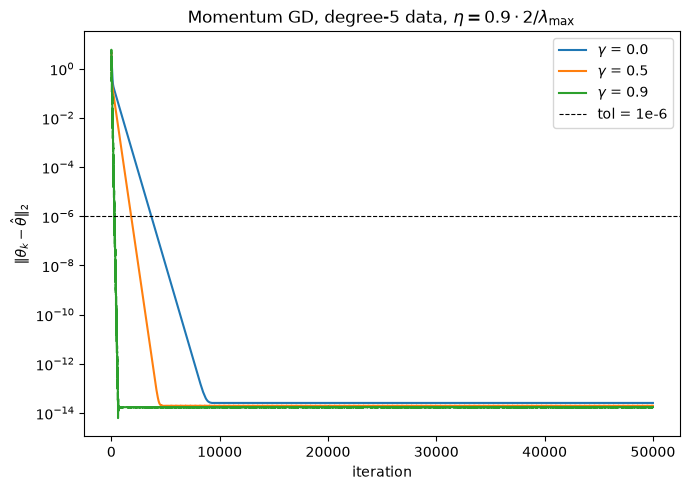

In [15]:
# Exercise 6: momentum gradient descent
#
# Reuse the degree-5 polynomial data set of exercise 4c) (X5_norm, y_centered),
# where plain OLS gradient descent is slow, together with its Hessian spectrum
# (lambda_min_5, lambda_max_5, kappa_5) computed there.

theta_hat_6 = np.linalg.solve(X5_norm.T @ X5_norm, X5_norm.T @ y_centered)
n6, p6 = X5_norm.shape

eta6 = 0.9 * 2 / lambda_max_5  # fixed learning rate, as specified


def momentum_gd(X, y, eta, gamma, num_iters=50_000, tol=1e-6):
    """Heavy-ball / momentum gradient descent for OLS, Eq. (4.23).
    Returns the distance-to-closed-form history and the first iteration at
    which that distance drops below tol (None if it never does)."""
    theta_hat = np.linalg.solve(X.T @ X, X.T @ y)
    n = X.shape[0]
    theta = np.zeros(X.shape[1])
    v = np.zeros(X.shape[1])
    dist_history = []
    n_reached = None
    for t in range(1, num_iters + 1):
        grad = 2 / n * X.T @ (X @ theta - y)
        v = gamma * v + eta * grad
        theta = theta - v
        dist = np.linalg.norm(theta - theta_hat)
        dist_history.append(dist)
        if not np.isfinite(dist) or dist > 1e8:
            break  # diverged
        if n_reached is None and dist < tol:
            n_reached = t
    return dist_history, n_reached


gammas = [0.0, 0.5, 0.9]
histories6 = {}
iters6 = {}

for gamma in gammas:
    hist, n_reached = momentum_gd(X5_norm, y_centered, eta6, gamma)
    histories6[gamma] = hist
    iters6[gamma] = n_reached
    status = f"{n_reached} iterations" if n_reached is not None else "did not converge"
    print(f"gamma = {gamma}: {status}")

plt.figure(figsize=(7, 5))
for gamma, hist in histories6.items():
    plt.semilogy(range(1, len(hist) + 1), hist, label=fr"$\gamma$ = {gamma}")
plt.axhline(1e-6, color="k", linestyle="--", linewidth=0.8, label="tol = 1e-6")
plt.xlabel("iteration")
plt.ylabel(r"$\|\theta_k - \hat\theta\|_2$")
plt.title(r"Momentum GD, degree-5 data, $\eta = 0.9\cdot 2/\lambda_{\max}$")
plt.legend()
plt.tight_layout()
plt.show()


**Results (part 1).** With $\eta = 0.9\cdot 2/\lambda_{\max} \approx 0.318$:

| $\gamma$ | iterations to $\|\theta_k-\hat\theta\|_2<10^{-6}$ |
|---|---|
| 0.0 | 3689 |
| 0.5 | 1829 |
| 0.9 | 284 |

Plain gradient descent ($\gamma=0$) needs 3689 iterations on this ill-conditioned ($\kappa\approx520$) problem —
consistent with exercise 4c. Adding momentum cuts this roughly in half at $\gamma=0.5$ and by more than
$13\times$ at $\gamma=0.9$, without changing $\eta$ at all: momentum is buying speed that a larger learning rate
could not, since $\eta$ is already pinned close to the stability edge $2/\lambda_{\max}$ by the *steep*
direction.

In [16]:
# Exercise 6, part 2: comparing the observed speed-up to sqrt(kappa),
# and trying the theoretically optimal momentum gamma*

sqrt_kappa_5 = np.sqrt(kappa_5)
gamma_star_5 = ((sqrt_kappa_5 - 1) / (sqrt_kappa_5 + 1)) ** 2

hist_star, n_star = momentum_gd(X5_norm, y_centered, eta6, gamma_star_5)

print(f"kappa_5 = {kappa_5:.4g}, sqrt(kappa_5) = {sqrt_kappa_5:.4g}")
print(f"gamma* = ((sqrt(kappa)-1)/(sqrt(kappa)+1))^2 = {gamma_star_5:.4g}")
print(f"gamma = gamma*, eta = eta6: {n_star} iterations")

speedup_09 = iters6[0.0] / iters6[0.9]
speedup_star = iters6[0.0] / n_star
print(f"\nSpeed-up gamma=0 -> gamma=0.9   : {speedup_09:.2f}x  (sqrt(kappa) = {sqrt_kappa_5:.2f})")
print(f"Speed-up gamma=0 -> gamma=gamma*: {speedup_star:.2f}x  (sqrt(kappa) = {sqrt_kappa_5:.2f})")

# The gamma* formula assumes eta is *also* set to the jointly optimal
# heavy-ball step size (2/(sqrt(lambda_max)+sqrt(lambda_min)))^2, not to the
# fixed eta6 used above -- check that combination as well.
eta_joint = (2 / (np.sqrt(lambda_max_5) + np.sqrt(lambda_min_5))) ** 2
hist_joint, n_joint = momentum_gd(X5_norm, y_centered, eta_joint, gamma_star_5)
print(f"\nJointly optimal eta* = {eta_joint:.4g}, gamma* = {gamma_star_5:.4g}: {n_joint} iterations "
      f"({iters6[0.0] / n_joint:.2f}x speed-up over gamma=0, eta6)")


kappa_5 = 520.3, sqrt(kappa_5) = 22.81
gamma* = ((sqrt(kappa)-1)/(sqrt(kappa)+1))^2 = 0.8391
gamma = gamma*, eta = eta6: 517 iterations

Speed-up gamma=0 -> gamma=0.9   : 12.99x  (sqrt(kappa) = 22.81)
Speed-up gamma=0 -> gamma=gamma*: 7.14x  (sqrt(kappa) = 22.81)

Jointly optimal eta* = 0.6494, gamma* = 0.8391: 214 iterations (17.24x speed-up over gamma=0, eta6)


**Results and discussion (part 2).**

$\kappa_5 \approx 520$, so $\sqrt{\kappa_5}\approx 22.8$: Eq. (4.26) predicts that well-tuned momentum should cut
the iteration count by *about* this factor relative to plain gradient descent's $\propto\kappa$ scaling.

| combination | iterations | speed-up over $\gamma=0$ |
|---|---|---|
| $\gamma=0$, $\eta=\eta_6$ | 3689 | 1$\times$ |
| $\gamma=0.9$, $\eta=\eta_6$ | 284 | **13.0$\times$** |
| $\gamma=\gamma^\star\approx0.839$, $\eta=\eta_6$ (fixed) | 517 | 7.1$\times$ |
| $\gamma=\gamma^\star$, $\eta=\eta^\star$ (jointly optimal) | 214 | **17.2$\times$** |

Both the $\gamma=0.9$ run and the jointly-optimal run land within the same order of magnitude as
$\sqrt{\kappa_5}\approx22.8$, confirming Eq. (4.26) qualitatively (not exactly $22.8\times$, since that scaling
is an asymptotic/worst-case rate, not an exact prediction for one fixed tolerance on one finite-dimensional
problem — and $\kappa$ here is not extreme enough that the asymptotic regime is fully reached).

The more interesting finding is that plugging $\gamma^\star$ into the *fixed* $\eta_6$ used in part 1
underperforms the empirically-tried $\gamma=0.9$ (517 vs. 284 iterations). This is because $\gamma^\star$ is
derived assuming $\eta$ is *also* set to its jointly-optimal heavy-ball value
$\eta^\star=\big(2/(\sqrt{\lambda_{\max}}+\sqrt{\lambda_{\min}})\big)^2\approx0.649$ (roughly twice $\eta_6$)
— $\gamma$ and $\eta$ are coupled, and tuning only one of them against a value optimised for the other can
undershoot. Using both optimal values together gives the best result of all (214 iterations, $17.2\times$),
close to the $\sqrt{\kappa}$ prediction. This is exactly the point made in the self-check: momentum trades one
data-dependent knob ($\eta$) for two ($\eta,\gamma$), and both must be set with the Hessian spectrum in mind.

**Part 3: why momentum speeds up flat directions and damps oscillation in steep ones.**

Diagonalise the (OLS) Hessian, $\boldsymbol H = \boldsymbol Q\boldsymbol\Lambda\boldsymbol Q^T$, and write the
error $\boldsymbol e_k=\boldsymbol\theta_k-\hat{\boldsymbol\theta}$ in the eigenbasis of
$\boldsymbol H$. Along eigendirection $j$ (eigenvalue $\lambda_j$) the momentum recursion (4.23) decouples into a
scalar linear recurrence,

$$
v_{k+1} = \gamma v_k + \eta\lambda_j e_k, \qquad e_{k+1} = e_k - v_{k+1},
$$

whose characteristic equation is $r^2-(1+\gamma-\eta\lambda_j)r+\gamma=0$ (Eq. (4.24)). Two regimes follow from
its discriminant:

* **Flat directions ($\lambda_j$ small, e.g. $\lambda_{\min}$).** The roots are real and close to $1$; the
  update behaves like *plain* gradient descent but with gradients from many past steps added together, since
  they all point the same way. Summing the geometric series in (4.23) gives an effective step size
  $\eta_{\mathrm{eff}} = \eta/(1-\gamma)$ (Eq. (4.25)): with $\gamma=0.9$ this is a $10\times$ larger effective
  learning rate in exactly the direction ($\lambda_{\min}$) that plain gradient descent could not afford to
  speed up without also destabilising $\lambda_{\max}$. This is *why* $\eta$ did not need to change in part 1 to
  get a large speed-up.
* **Steep directions ($\lambda_j$ large, e.g. $\lambda_{\max}$).** Here $\eta\lambda_j$ is close to its
  stability limit and the roots of the characteristic equation become a complex-conjugate pair with magnitude
  $\sqrt\gamma$ (Eq. (4.24)), *independent of $\lambda_j$*: instead of the error growing or oscillating with
  amplitude governed by $|1-\eta\lambda_j|$ as in plain gradient descent, momentum turns the update into a
  damped oscillation that shrinks by a factor $\sqrt\gamma<1$ every step regardless of how large $\lambda_j$ is.
  The gradient in this direction keeps flipping sign step to step, so consecutive contributions to $v_k$
  partially cancel instead of accumulating — the opposite of the flat-direction case.

Because the *same* $(\eta,\gamma)$ pair damps the steep direction (via cancellation, rate $\sqrt\gamma$) while
accelerating the flat direction (via accumulation, effective step $\eta/(1-\gamma)$), the slowest-converging
direction overall improves from a rate governed by $\kappa$ to one governed by $\sqrt\kappa$ — exactly Eq. (4.26)
and what part 2 verified numerically.

In [17]:
# Exercise 6, part 4 (optional): eta above the plain-GD stability limit

eta_big = 1.5 * 2 / lambda_max_5
print(f"eta_big = 1.5 * 2/lambda_max_5 = {eta_big:.4g}  (plain GD needs eta < {2/lambda_max_5:.4g})")

for gamma in [0.0, 0.5, 0.9, gamma_star_5]:
    hist, n_reached = momentum_gd(X5_norm, y_centered, eta_big, gamma, num_iters=50_000)
    if n_reached is not None:
        status = f"converged in {n_reached} iterations"
    elif not np.isfinite(hist[-1]) or hist[-1] > 1e8:
        status = f"diverged (||theta_k - theta_hat|| -> {hist[-1]:.3g})"
    else:
        status = f"did not reach tol within budget (final dist = {hist[-1]:.3g})"
    print(f"  gamma = {gamma:.4g}: {status}")


eta_big = 1.5 * 2/lambda_max_5 = 0.5307  (plain GD needs eta < 0.3538)
  gamma = 0: diverged (||theta_k - theta_hat|| -> 1.83e+08)


  gamma = 0.5: did not reach tol within budget (final dist = 1.02)


  gamma = 0.9: converged in 277 iterations


  gamma = 0.8391: converged in 265 iterations


**Results and discussion (part 4, optional).** At $\eta=1.5\cdot2/\lambda_{\max}\approx0.531$ — 50% above the
plain-gradient-descent stability limit:

| $\gamma$ | outcome |
|---|---|
| 0.0 | diverges |
| 0.5 | does not reach tolerance within 50000 iterations (stuck oscillating, final distance $\approx1.0$) |
| 0.9 | converges in 277 iterations |
| $\gamma^\star\approx0.839$ | converges in 265 iterations |

Plain gradient descent ($\gamma=0$) diverges exactly as expected, since $\eta$ violates Eq. (4.20). Momentum
shifts the stability boundary to $\eta<2(1+\gamma)/\lambda_{\max}$: at $\gamma=0.9$ the effective bound is
$1.9\times2/\lambda_{\max}$, comfortably above the $1.5\times$ used here, so the run not only survives but
converges *faster* than the $\gamma=0.9$ run of part 1 (277 vs. 284 iterations) — a bigger $\eta$ is now usable
because momentum is damping the steep direction itself, per part 3. $\gamma=0.5$ sits in between: its stability
bound $1.5\times2/\lambda_{\max}$ is right at the edge of $\eta_{\mathrm{big}}$, so the steep direction is only
marginally damped and the run stalls rather than diverging outright or converging cleanly — a reminder that the
stability boundary moving with $\gamma$ is not the same as convergence being fast anywhere near that boundary.

## Insights you should have gained this week — a self-check

Before you hand in, go through the list below without looking at the notes.
Each row is a question we may ask in the Tuesday session or on Project 1; the
right-hand column is the insight it tests, in one sentence.

| Ask yourself | The insight it tests |
|---|---|
| My loop stopped after its allowed iterations with a small but nonzero gradient. Has it converged? | No. Along the slowest direction the error contracts by $\lvert 1-\eta\lambda_{\min}\rvert$ per step, Eq. (4.19), and can still be $\|\nabla C\|/\lambda_{\min}$ large. Stop on the gradient (or on $\Delta\boldsymbol{\theta}$), never on a count alone. |
| Why does gradient descent care about the scaling of the columns when the closed form does not? | The closed form solves the normal equations in one go; gradient descent takes the same step in every direction, and the column scales set the eigenvalue spread $\kappa(\boldsymbol{H}) = \kappa_2(\boldsymbol{X})^2$, Eq. (4.22), hence the iteration count. Same minimum, different road. |
| Ridge converged in far fewer iterations than OLS. Did it find a better OLS solution? | No — it found the exact solution of a *different* problem, Eq. (4.16). The penalty lifts $\lambda_{\min}$, Eq. (4.17), which shortens the road, but the destination moved: bias traded for variance. |
| The same code diverged at $\eta = 0.5$ on one data set and converged at $\eta = 0.8$ on another. Why? | Stability requires $\eta < 2/\lambda_{\max}$, Eq. (4.20), and $\lambda_{\max}$ is a property of $\boldsymbol{X}$, not of the algorithm. Compute it — `np.linalg.eigvalsh(2/n * X.T @ X).max()` — before you choose $\eta$. |
| The closed form and my converged gradient descent disagree in the second decimal for Ridge. Which is wrong? | Possibly neither: with the cost $\frac{1}{n}\|\boldsymbol{X}\boldsymbol{\theta}-\boldsymbol{y}\|^2 + \lambda\|\boldsymbol{\theta}\|^2$ the closed form has $n\lambda\boldsymbol{I}$, Eq. (3.95), and `scikit-learn`'s `alpha` is $n\lambda$. Compare cost functions before comparing methods. |
| My JAX gradient agrees with my analytical gradient to $10^{-15}$. What have I proved? | That your derivation matches the cost you *wrote down* — an algebra error would show as $10^{-2}$. Not that the cost is the one you meant (a missing $1/n$, a penalised intercept): both gradients would then agree and both would be wrong. |
| Momentum converged where plain gradient descent diverged. Is the learning rate now unimportant? | No. The stability edge moves to $2(1+\gamma)/\lambda_{\max}$, and the best $\gamma$ is tied to $\kappa$ through Eq. (4.26); too much momentum rings for ever. Two data-dependent knobs instead of one. |
| Why does momentum help, in one sentence? | It adds up gradients that keep pointing the same way (the flat directions, effective step $\eta/(1-\gamma)$, Eq. (4.25)) and cancels gradients that alternate in sign (the steep direction), so the iteration count scales with $\sqrt\kappa$ instead of $\kappa$. |
| I swap the OLS cost for a neural-network cost and keep `jax.grad`. What changes? | In the code: only the definition of the cost. In the theory: convexity is gone, so a stationary point need not be the global minimum (Section 4.1) and the bound of Eq. (4.20) is only local — good behaviour becomes empirical, not a theorem. |
| Why reverse mode for training, and what is its price? | One scalar output and $p$ inputs: reverse mode returns the full gradient for two or three cost evaluations, whatever $p$ (the cheap gradient principle, Section 4.14.4); forward mode or finite differences would need $p$ sweeps. The price is the tape — every intermediate value is stored until the backward sweep has used it: memory, not time. |
| Why not just use finite differences to check the gradient, and be done with it? | For a *quadratic* cost the central difference is exact up to rounding, so it would pass; for anything else its best accuracy is about $10^{-11}$ at $h\approx10^{-6}$, Eq. (4.46), and it costs $2p$ evaluations. Use it as a check at $h \approx 10^{-5}$, not as the gradient. |

### Practicalities

Deliver your solutions (a single Jupyter notebook, with the analytical parts
either typeset in Markdown/LaTeX or as a scanned handwritten note) in Canvas
before **Friday September 11 at midnight**. Collaboration is encouraged — list
your collaborators.